In [4]:
import numpy as np
import pandas as pd
import polars as pl
import scienceplots
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator, RegularGridInterpolator
from scipy.optimize import differential_evolution
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import h5py
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import math
from scipy import integrate
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from whittaker_eilers import WhittakerSmoother
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image, ImageSequence
from scipy.spatial import cKDTree
from itertools import product
from numpy import load
import skrf as rf


plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({'font.size': 12})
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{siunitx}"
plt.rcParams["figure.figsize"] = (14, 7) 

In [2]:
def read_istar_data(filename, weird_slash = False, bias_current_var = True):
    str1 = '#freq(Hz)	S21_dB	S21_deg'
    str2 = '#freq(Hz)	CH1_S11_1=S11_real	CH1_S11_1=S11_imag'
    if bias_current_var == True:
        if weird_slash == True:
            a = filename.split("\\")
        else:
            a = filename.split("/")
        for i in a:
            if ".txt" in i:
                start_index = i.index("p")
                stop_index = i.index("V")
                
                bias_current = (str(i[start_index-1]) + "." + str(i[start_index+1: stop_index]))
                bias_current = float(bias_current)
    
    start_writing = False
    freqs = []
    s21_db = []
    s21_deg = []
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            j = (line.strip())
            if ('#freq(Hz)' in j):
                start_writing = True
            if start_writing == True:
                if (j.split() != []) and (j.find('#freq(Hz)') == -1):
                    freqs.append(float(j.split()[0]))
                    s21_db.append(float(j.split()[1]))
                    s21_deg.append(float(j.split()[2]))
                    
    if bias_current_var == True:
        return [bias_current, np.array(freqs), np.array(s21_db), np.pi/180*np.array(s21_deg)]    
    else:
        return [np.array(freqs), np.array(s21_db), np.pi/180*np.array(s21_deg)]

def m_to_istar(m):
    return np.sqrt(1/m)

def quadratic_fit(x, a):
    return a*x**2


In [3]:
freqs, s21_mag, s21_phase = read_istar_data("b5b6twpa/twpa_data/qubic_b6_s21_db_deg_biastees_0p020251104-131941.txt", bias_current_var=False)

FileNotFoundError: [Errno 2] No such file or directory: 'b5b6twpa/twpa_data/qubic_b6_s21_db_deg_biastees_0p020251104-131941.txt'

In [ ]:
freqsch, s21_magch, s21_phasech = read_istar_data("b5b6twpa/11072025 Cold S21/S21_high_average_input_7_to_18GHz_vna_readval_0.txt", bias_current_var=False)

In [ ]:

plt.plot(freqs/1e9, s21_mag)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Magnitude (dB)')
plt.show()

plt.plot(freqs/1e9, s21_phase)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Unwrapped Phase (rad)')
plt.show()

plt.plot(freqsch/1e9, s21_magch)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Real')
plt.show()

plt.plot(freqsch/1e9, s21_phasech)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Imaginary')
plt.show()

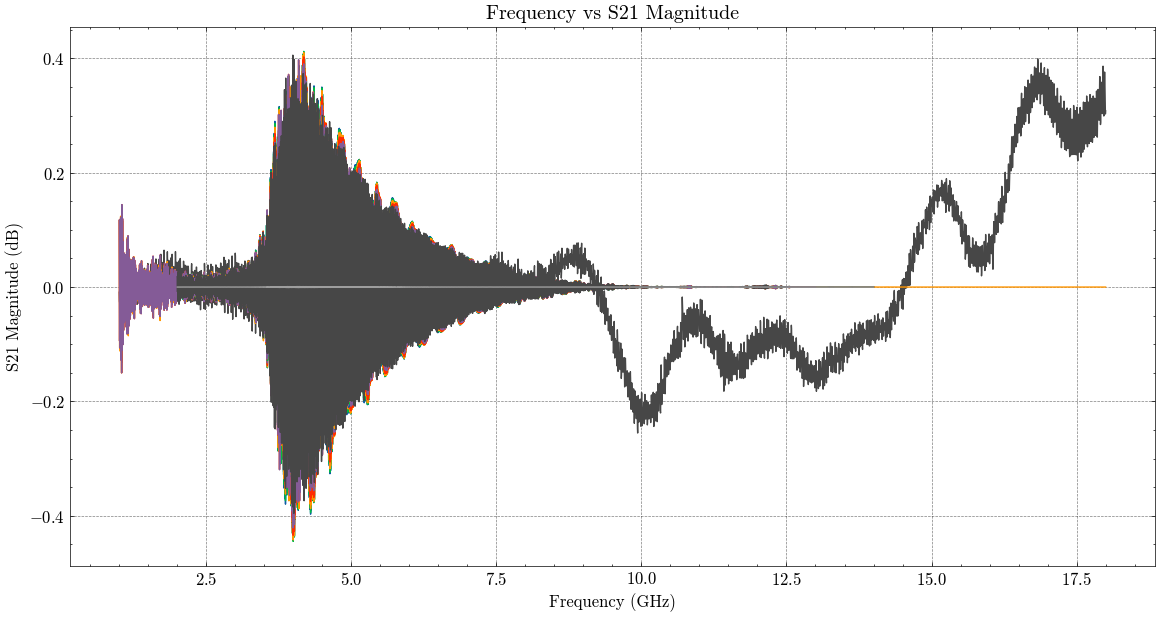

In [4]:
for f in Path("b5b6twpa/twpa_data").glob("*.txt"):
    freqs, s21mag, s21phase = read_istar_data(f, bias_current_var=False)
    
    plt.plot(freqs/1e9, s21mag)
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('S21 Magnitude (dB)')
    plt.title('Frequency vs S21 Magnitude')

    
    # plt.plot(freqs/1e9, s21phase)
    # plt.xlabel('Frequency (GHz)')
    # plt.ylabel('S21 Unwrapped Phase (rad)')

plt.show() 
for f in Path("b5b6twpa/11072025 Cold S21").glob("*.txt"):
    freqsch, s21magch, s21phasech = read_istar_data(f, bias_current_var=False)
    
    plt.plot(freqsch/1e9, s21magch)
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('S21 Magnitude (dB)')
    plt.title('Frequency vs S21 Magnitude')
    

In [5]:
def istar_expression_vars(bias_current, zero_bias, phase, k_vector, frequency_twpa, frequency_band):
    '''
    This function is essentially the same as istar_expression, except that instead of taking the files
    and doing all the math and getting to the final istar plot, we do it with just the raw data that is 
    provided instead. 
    
    --- Inputs --- 
    bias_current        : The bias current value (mA) at which we are measuring the phases
    zero_bias           : A list that contains the frequency and phase arrays of the zero bias current data, [frequency, phase]
    phase               : The np.array that contains the bias current dependent phase data 
    k_vector            : The np.array that contains the k_vector data from the dispersion plot
    frequency_twpa      : The np.array that contains the frequency data from the dispersion plot (GHz)
    frequency_band      : This is the frequency at which you want to calculate I_star
    
     --- Outputs --- 
    A list of the x and y values are returned. The x value is the bias current value (mA) and the y value is the other 
    side of the equation used to calculate I_star, basically the total phase change. 
    '''
    ## Important Values
    N_sc = 320.0
    L_sc = (35.0*15.0)/10**6
    
    ## Step 1 - Speed of Light and Traversal Time Calculations
    omega = 2*np.pi*frequency_twpa*1e9 
    phase_velocity = (omega/k_vector)
    tau_twpa = (N_sc*L_sc)/phase_velocity
    
    ## Step 2 - Relative Phase
    freqs = zero_bias[0]
    phase_naught = zero_bias[1]
    indices_phase = np.where(freqs >= frequency_band)
    indices_twpa = np.where(frequency_twpa*1e9 >= frequency_band)
    index_phase = indices_phase[0][0]
    index_twpa = indices_twpa[0][0]
    
    theta_I = phase[index_phase]
    theta_0 = phase_naught[index_phase]
    theta_r = 2*np.pi*frequency_band*tau_twpa[index_twpa]
    
    ## Step 3 - Final Expression
    x = bias_current
    y = -2*((theta_I-theta_0)/theta_r)
    
    return [x, y]

def calculating_istar_vars(folder_name, frequency_band):
    '''
    Again this function takes the entire folder in which the bias current depdendant phase data is kept to
    calculate the istar expression. It is the same as the calculating_istar function, except this function 
    is again a continuation of the istar_expression_vars and thus will deal with the getting the data from 
    the .txt files (basically any files that aren't the regular .hdf5 files, can be tweaked later). 
    
    --- Inputs ---
    folder_name         : The name of the folder in which the bias current dependent data is kept
    frequency_band      : The frequency at which you want to do the Istar fitting
    
    --- Outputs --- 
    A list of the istar fit value with the corresponding error as well. 
    '''
    N_sc = 320.0
    L_sc = (35.0*15.0)/10**6
    
    dc_currents = []
    delta_thetas = []
    
    freqs, _ , phase_naught = read_istar_data("b5b6twpa/istar_test1/qubic_b6_s21_db_deg_biastees_0p0V20251104-131941.txt", bias_current_var=False)
    zero_bias_data = [freqs, phase_naught]
    
    data = load("istar_data/k.npz")
    lst = data.files
    frequency_twpa = data[lst[0]]
    k_vector = data[lst[1]]/L_sc  
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.txt"):
        bias_current, _ , _ ,phase = read_istar_data(str(f), weird_slash=True)
        x, y = istar_expression_vars(bias_current, zero_bias_data, phase, k_vector, frequency_twpa, frequency_band)
        dc_currents.append(x)
        delta_thetas.append(y)
    
    dc_currents = np.array(dc_currents)
    delta_thetas = np.array(delta_thetas)
            
    param, cov = curve_fit(quadratic_fit, dc_currents, delta_thetas)
    perr = np.sqrt(np.diag(cov))
    m_fit = param
    m_fit_error = perr
    
    # fitted_y = quadratic_fit(dc_currents, m_fit)
    
    # plt.plot(dc_currents, delta_thetas, 'o', label='Raw Data')
    # plt.plot(dc_currents, fitted_y, label='Linear Fit')
    # plt.xlabel(r'$I_{dc}$' + " (mA)")
    # plt.ylabel(r'$-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}$')
    # plt.legend()
    # plt.show()
    
    return [m_to_istar(m_fit), m_to_istar(m_fit_error)]
          

In [ ]:
istar_frequencies = np.linspace(5e9, 13e9, 200)
istars = []
istars_err = []

for i in istar_frequencies:
    istars.append(calculating_istar_vars("b5b6twpa/istar_test1/bias_depdendent_phase", i)[0][0])
    istars_err.append(calculating_istar_vars("b5b6twpa/istar_test1/bias_depdendent_phase", i)[1][0])

istars = np.array(istars)    
istars_err = np.array(istars_err)

In [ ]:

full_band_avg = np.mean(istars)
full_band_std = np.std(istars)

mask = np.where((istar_frequencies >= 4e9) & (istar_frequencies <= 8e9))
banded_avg = np.mean(istars[mask])
banded_std = np.std(istars[mask])

plt.plot(istar_frequencies/1e9, istars, '+', label='Data')
# plt.axhline(y=full_band_avg, linestyle='--', color='forestgreen', label='Full Band I*')
# plt.axhspan(full_band_avg - full_band_std, full_band_avg + full_band_std, alpha=0.15, color='forestgreen')
plt.axhline(y=banded_avg, linestyle='--', label='4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg, 2)) + ' mA')
plt.axhspan(banded_avg - banded_std, banded_avg + banded_std, alpha=0.25)
plt.xlabel('Frequncy (GHz)')
plt.ylabel(r'$I_{*}$' + ' (mA)')
plt.title('Frequency vs ' + r'$I_{*}$' + ' Measurements')
plt.legend()
plt.ylim(0, 8)
plt.show()

In [ ]:
import math

Istar = 3*math.sqrt(3)/2*(3)
I_dc = (2*(5.44))/(3*math.sqrt(3))
print(Istar, I_dc)

In [ ]:
def get_bias_current(filename):
    filename = str(filename)
    start = filename.split('\\')[3].split('_')[2].split('.')[0].split('p')[0]
    stop = filename.split('\\')[3].split('_')[2].split('.')[0].split('p')[1].split('V')[0]

    bias_current = str(start + '.' + stop)
    bias_current = float(bias_current)
    return bias_current


bias_currents = []
s21_magnitudes = []
s21_phases = []
s21_unwrapped = []
frequencies = []
folder_path = Path("b5b6twpa/initial_bias_current_sweeps/b6")
for f in folder_path.glob("*.s2p"):
    network = rf.Network(f)
    freqs = network.f
    s21 = network.s[:, 1, 0]
    magnitude = 20*np.log10(np.abs(s21))
    phase = np.angle(s21)
    unwrapped_phase = np.unwrap(phase)
    bias_current = get_bias_current(f)
    
    bias_currents.append(bias_current)
    frequencies.append(freqs)
    s21_magnitudes.append(magnitude)
    s21_phases.append(phase)
    s21_unwrapped.append(unwrapped_phase)

ibias_sweep = np.array(bias_currents)    
frequency_sweep = frequencies[0]
magnitude_sweep = np.vstack(s21_magnitudes)
phase_sweep = np.vstack(s21_phases)
unwrapped_sweep = np.vstack(s21_unwrapped)

plt.pcolormesh(frequency_sweep/1e9, ibias_sweep, magnitude_sweep, shading='auto', cmap='viridis')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Bias Current (mA)')
plt.title('I Bias Sweep, Pump Off')
cbar = plt.colorbar()
cbar.set_label('S21 Magnitude (dB)')
plt.tight_layout()
plt.show()

print(frequency_sweep.shape, ibias_sweep.shape, magnitude_sweep.shape)

plt.pcolormesh(frequency_sweep/1e9, ibias_sweep, phase_sweep, shading='auto', cmap='viridis')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Bias Current (mA)')
plt.title('I Bias Sweep, Pump Off')
cbar = plt.colorbar()
cbar.set_label('S21 Wrapped Phase (rad)')
plt.tight_layout()
plt.show()

plt.pcolormesh(frequency_sweep/1e9, ibias_sweep, unwrapped_sweep, shading='auto', cmap='viridis')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Bias Current (mA)')
plt.title('I Bias Sweep, Pump Off')
cbar = plt.colorbar()
cbar.set_label('S21 Unwrapped Phase (rad)')
plt.tight_layout()
plt.show()

In [ ]:
network = rf.Network("b5b6twpa/initial_bias_current_sweeps/b5/10_in_2p2V.s2p")

frequencies = network.f
s21 = network.s[:, 1, 0]

magnitude = 20*np.log10(np.abs(s21))
phase = np.angle(s21)
unwrapped_phase = np.unwrap(phase)

plt.plot(frequencies/1e9, magnitude)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Magnitude (dB)')
plt.show()

plt.plot(frequencies/1e9, phase)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Wrapped Phase (rad)')
plt.show()

plt.plot(frequencies/1e9, unwrapped_phase)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Unwrapped Phase (rad)')
plt.show()

In [ ]:


def get_data_s2p(filename, slash = False, b6=True):
    network = rf.Network(filename)
    
    frequencies = network.f
    s21 = network.s[:, 1, 0]
    if b6 == False:
        
    else:    
        magnitude = 20*np.log10(np.abs(s21))
        phase = np.angle(s21)
        unwrapped_phase = np.unwrap(phase)
        
    if slash == True:
        bias_current = (np.float64(filename.split('\\')[3].split('_')[2].split('.')[0].replace('p', '.')[:-1]))
    else:
        bias_current = (np.float64(filename.split('/')[2].split('_')[2].split('.')[0].replace('p', '.')[:-1]))
    
    return [bias_current, frequencies, magnitude, phase, unwrapped_phase]

## line 9 is B6, line 10 is B5


In [ ]:
def calculating_istar_vars_fridge(folder_name, frequency_band):
    '''
    Again this function takes the entire folder in which the bias current depdendant phase data is kept to
    calculate the istar expression. It is the same as the calculating_istar function, except this function 
    is again a continuation of the istar_expression_vars and thus will deal with the getting the data from 
    the .txt files (basically any files that aren't the regular .hdf5 files, can be tweaked later). 
    
    --- Inputs ---
    folder_name         : The name of the folder in which the bias current dependent data is kept
    frequency_band      : The frequency at which you want to do the Istar fitting
    
    --- Outputs --- 
    A list of the istar fit value with the corresponding error as well. 
    '''
    N_sc = 320.0
    L_sc = (35.0*15.0)/10**6
    
    dc_currents = []
    delta_thetas = []
    
    _, freqs, _, _, phase_naught = get_data_s2p("b5b6twpa/initial_bias_current_sweeps/9_in_0p0V.s2p")
    zero_bias_data = [freqs, phase_naught]
    
    data = load("istar_data/k.npz")
    lst = data.files
    frequency_twpa = data[lst[0]]
    k_vector = data[lst[1]]/L_sc  
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.s2p"):
        bias_current, _ , _ , _, phase = get_data_s2p(str(f), slash=True)
        x, y = istar_expression_vars(bias_current, zero_bias_data, phase, k_vector, frequency_twpa, frequency_band)
        dc_currents.append(x)
        delta_thetas.append(y)
    
    dc_currents = np.array(dc_currents)
    delta_thetas = np.array(delta_thetas)

    param, cov = curve_fit(quadratic_fit, dc_currents, delta_thetas)
    perr = np.sqrt(np.diag(cov))
    m_fit = param
    m_fit_error = perr
    
    # fitted_y = quadratic_fit(dc_currents, m_fit)
    
    # plt.plot(dc_currents, delta_thetas, 'o', label='Raw Data')
    # plt.plot(dc_currents, fitted_y, label='Linear Fit')
    # plt.xlabel(r'$I_{dc}$' + " (mA)")
    # plt.ylabel(r'$-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}$')
    # plt.legend()
    # plt.show()
    
    return [m_to_istar(m_fit), m_to_istar(m_fit_error)]

In [ ]:
istar_frequencies = np.linspace(3e9, 9e9, 100)
istars_b6 = []
istars_err = []
istars_b5 = []

for i in istar_frequencies:
    istars_b6.append(calculating_istar_vars_fridge("b5b6twpa/initial_bias_current_sweeps/b6", i)[0][0])
    istars_b5.append(calculating_istar_vars_fridge("b5b6twpa/initial_bias_current_sweeps/b5", i)[0][0])


istars_b6 = np.array(istars_b6) 
istars_b5 = np.array(istars_b5)   
# istars_err = np.array(istars_err)

mask = np.where((istar_frequencies >= 4e9) & (istar_frequencies <= 8e9))
banded_avg = np.mean(istars_b6[mask])
banded_std = np.std(istars_b6[mask])
banded_avg_b5 = np.mean(istars_b5[mask])
banded_std_b5 = np.std(istars_b5[mask])
 
plt.plot(istar_frequencies/1e9, istars_b6, '+', color='cornflowerblue', label='B6 I* Data')
plt.plot(istar_frequencies/1e9, istars_b5, '+', color='mediumpurple', label='B5 I* Data')
plt.axhline(y=banded_avg, linestyle='--', color='cornflowerblue', label='B6 4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg, 2)) + ' mA')
plt.axhspan(banded_avg - banded_std, banded_avg + banded_std, color='cornflowerblue', alpha=0.25)
plt.axhline(y=banded_avg_b5, linestyle='--', color='mediumpurple', label='B5 4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg_b5, 2)) + ' mA')
plt.axhspan(banded_avg_b5 - banded_std_b5, banded_avg_b5 + banded_std_b5, color='mediumpurple', alpha=0.25)
plt.xlabel('Frequncy (GHz)')
plt.ylabel(r'$I_{*}$' + ' (mA)')
plt.title('Frequency vs ' + r'$I_{*}$' + ' Measurements')
plt.legend()
plt.show()

In [ ]:
plt.plot(istar_frequencies/1e9, istars_b6, '+', color='cornflowerblue', label='B6 I* Data')
plt.plot(istar_frequencies/1e9, istars_b5, '+', color='mediumpurple', label='B5 I* Data')
plt.axhline(y=banded_avg, linestyle='--', color='cornflowerblue', label='B6 4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg, 2)) + ' mA')
plt.axhspan(banded_avg - banded_std, banded_avg + banded_std, color='cornflowerblue', alpha=0.25)
plt.axhline(y=banded_avg_b5, linestyle='--', color='mediumpurple', label='B5 4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg_b5, 2)) + ' mA')
plt.axhspan(banded_avg_b5 - banded_std_b5, banded_avg_b5 + banded_std_b5, color='mediumpurple', alpha=0.25)
plt.xlabel('Frequncy (GHz)')
plt.ylabel(r'$I_{*}$' + ' (mA)')
plt.title('Frequency vs ' + r'$I_{*}$' + ' Measurements')
plt.ylim(0, 8.5)
plt.legend()
plt.show()

In [ ]:
sdig = '0p0V'
sdig[:sdig.find('V')].replace('p', '.')

In [ ]:
metadata_file = 'b5b6twpa/S21_B6_1.5volt_pump_power_pump_frequency_sweep_v1.txt'

start_writing = False
pump_frequencies = []
pump_powers = []
with open(metadata_file, 'r', encoding='utf-8') as file:
        for line in file:
            j = (line.strip())
            if ('#wind.rf_level_dBm	wind.freq_MHz	vna.readval	bc.tmxc	time' in j):
                start_writing = True
            if (start_writing == True) and (j.split() != []) and (j.find('#wind.rf_level_dBm	wind.freq_MHz	vna.readval	bc.tmxc	time') == -1):
                pump_frequencies.append((np.float64(j.split()[1])))
                pump_powers.append((np.float64(j.split()[0])))
pump_frequencies = np.array(pump_frequencies)
pump_powers = np.array(pump_powers)
_, power_split_indices = np.unique(pump_powers, return_index=True)
power_split_indices

array([   0,  601, 1202, 1803, 2404])

In [ ]:
realdata_file = 'b5b6twpa/b6_paramscans/S21_B6_1.5volt_pump_power_pump_frequency_sweep_v1_vna_readval_0000.txt'

def convert_realimag_to_dbdeg(filename):
    start_writing = False
    signal_frequencies = []
    s21_real = []
    s21_imag = []
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            j = (line.strip())
            if ('#freq(Hz)' in j):
                start_writing = True
            if (start_writing == True) and (j.split() != []) and (j.find('#freq(Hz)') == -1):
                signal_frequencies.append(np.float64(j.split()[0]))
                s21_real.append(np.float64(j.split()[1]))
                s21_imag.append(np.float64(j.split()[2]))
    signal_frequencies = np.array(signal_frequencies)
    s21_real = np.array(s21_real)
    s21_imag = np.array(s21_imag) 

    ## To convert to mag and phase in dB, deg
    s21_magnitude = 20*np.log10((s21_real**2 + s21_imag**2)**(1/2))   
    s21_phase = np.arctan(s21_imag/s21_real)
    # s21_phase = [] 
    # for i in range(0, len(s21_real)):
    #     if ((s21_real[i] > 0) and (s21_imag[i] > 0)) or ((s21_real[i] > 0) and (s21_imag[i] < 0)):
    #         s21_phase.append(np.arctan(s21_imag[i]/s21_real[i]))
    #     elif (s21_real[i] < 0) and (s21_imag[i] > 0):
    #         s21_phase.append(np.arctan(s21_imag[i]/s21_real[i]) + 180)
    #     else:
    #         s21_phase.append(np.arctan(s21_imag[i]/s21_real[i]) - 180)
    # s21_phase = np.array(s21_phase)
    
    return [signal_frequencies, s21_magnitude, s21_phase]

s21_b5_magnitudes = []
signal_frequency = []
folder_path = Path("b5b6twpa/b6_paramscans")
for f in folder_path.glob("*.txt"):
    s21_b5_magnitudes.append(convert_realimag_to_dbdeg(f)[1])
    signal_frequency.append(convert_realimag_to_dbdeg(f)[0])

pumppower_splitted_s21_b5_magnitudes = np.split(s21_b5_magnitudes, power_split_indices)

# for i in pumppower_splitted_s21_b5_magnitudes:
#     i = np.vstack(i)
#     plt.pcolormesh(signal_frequency[0]/1e9, pump_powers, i, shading='auto', cmap='inferno')
#     plt.xlabel('Signal Frequency (GHz)')
#     plt.ylabel('Pump Frequency (GHz)')
#     plt.title('Pump Sweep')
#     cbar = plt.colorbar()
#     cbar.set_label('S21 Magnitude (dB)')
#     plt.tight_layout()
#     plt.show()

In [ ]:
signal_freq = np.array(signal_frequency[0])

In [ ]:
pumppower_splitted_s21_b5_magnitudes[5]

array([[-42.56114375, -42.36222508, -42.18335799, ..., -49.47940277,
        -49.89944502, -53.1927327 ],
       [-42.29787625, -42.3451509 , -42.20912411, ..., -49.60463927,
        -50.16562162, -53.24101351],
       [-42.18370522, -42.28553101, -42.18029159, ..., -49.58372287,
        -49.3121639 , -52.73410443],
       ...,
       [-42.40340828, -42.34098489, -42.27115315, ..., -50.65406086,
        -50.13120969, -53.02967119],
       [-42.46318551, -42.2971994 , -42.01194115, ..., -49.97092334,
        -50.21510723, -52.77134603],
       [-42.35916914, -42.36848641, -42.10073485, ..., -50.0469322 ,
        -50.24672966, -52.94015842]], shape=(601, 3001))

In [ ]:
print(signal_freq.shape)
pump_frequencies = pump_frequencies[0:601]

(3001,)


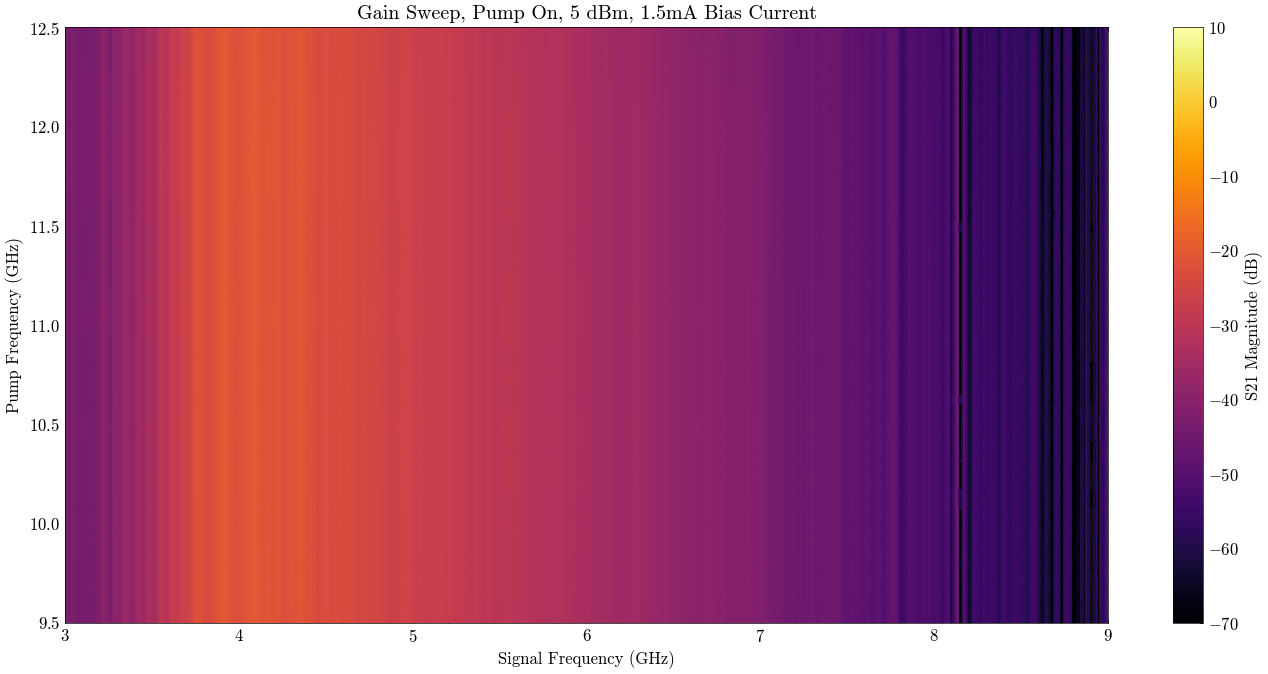

In [ ]:
plt.pcolormesh(signal_freq/1e9, 
               pump_frequencies/1000, 
               np.vstack(pumppower_splitted_s21_b5_magnitudes[5]), 
               shading='auto', cmap='inferno', vmin=-70, vmax=10)
plt.xlabel('Signal Frequency (GHz)')
plt.ylabel('Pump Frequency (GHz)')
plt.title('Gain Sweep, Pump On, 5 dBm, 1.5mA Bias Current')
cbar = plt.colorbar()
cbar.set_label('S21 Magnitude (dB)')
plt.tight_layout()
plt.show()

In [ ]:
To get access to fridge data 
bc = instruments.bf_controller()

get bc.tmxc
get bc.tstill
get bc.t4k
get bc.t50k

To connect to instrument (Voltage source)
rg = instruments.rigol("USB0::0x1AB1::0xA4A8::DP9A263900937::0::INSTR")

To set voltage
set(rg.voltage,1)

sweep(wind.freq_MHz,9500, 12500, 601,out= [vna.readval,bc.tmxc], filename = "S21_pump_frequency_sweep_9p5to12p5_5MHz_p5dbmpump_2p25vdc_n10dbmsignal.txt")

In [ ]:
### Loops Setup ### 
bias_current_start = 
bias_current_stop = 
bias_current_step = 

pump_power_start = 
pump_power_stop = 
pump_power_step = 

pump_frequency_start = 
pump_frequency_stop = 
pump_frequency_step = 

bias_currents = np.arange(bias_current_start, bias_current_stop, bias_current_step)
pump_powers = np.arange(pump_power_start, pump_power_stop, pump_power_step)
pump_frequencies = np.arange(pump_frequency_start, pump_frequency_stop, pump_frequency_step)

### Interlock Setup ###
mxc_temp_interlock = 250
still_temp_interlock = 815

### Executing Loops ### 
for bias_current in bias_currents:
    for pump_power in pump_powers:
        set(rg.voltage, bias_current)
        set(wind.rf_level_dBm, pump_power)
        sweep(wind.freq_MHz,pump_frequency_start, pump_frequency_stop, 601,out= [vna.readval,bc.tmxc], filename = "S21_pump_frequency_sweep_" + "9p5to12p5_5MHz" + "_p5dbmpump_2p25vdc_n10dbmsignal.txt")

In [ ]:
pump_power = -5.5
bias_current = 2.25

pump_str = str(pump_power).replace(".", "p")
bias_str = str(bias_current).replace(".", 'p')
filename = "S21_pump_frequency_sweep" + "9p5to12p5_5MHz_" + pump_str + "dbmpump_" + bias_str + "Vdc_n10dbmsignal.txt"
print(filename)

In [ ]:
def extract_data(filename):
    start_writing = False
    freqs = []
    s21_real = []
    s21_imag = []
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            j = (line.strip())
            if ('#freq(Hz)' in j):
                start_writing = True
            if start_writing == True:
                if (j.split() != []) and (j.find('#freq(Hz)') == -1):
                    freqs.append(j.split()[0])
                    s21_real.append(j.split()[1])
                    s21_imag.append(j.split()[2])
    freqs = np.array(freqs)
    s21_real = np.array(s21_real)
    s21_imag = np.array(s21_imag)
    return [freqs, s21_real, s21_imag]

f, s21m, s21p = convert_realimag_to_dbdeg('b5b6twpa/QubicTech/resonator_DC_bias/resonator_DC_bias_20dBAtt_0dBm_2to16GHz_bandwith_100Hz_3001_npt_vna_readval_000.txt')

(2.0, 4.0)

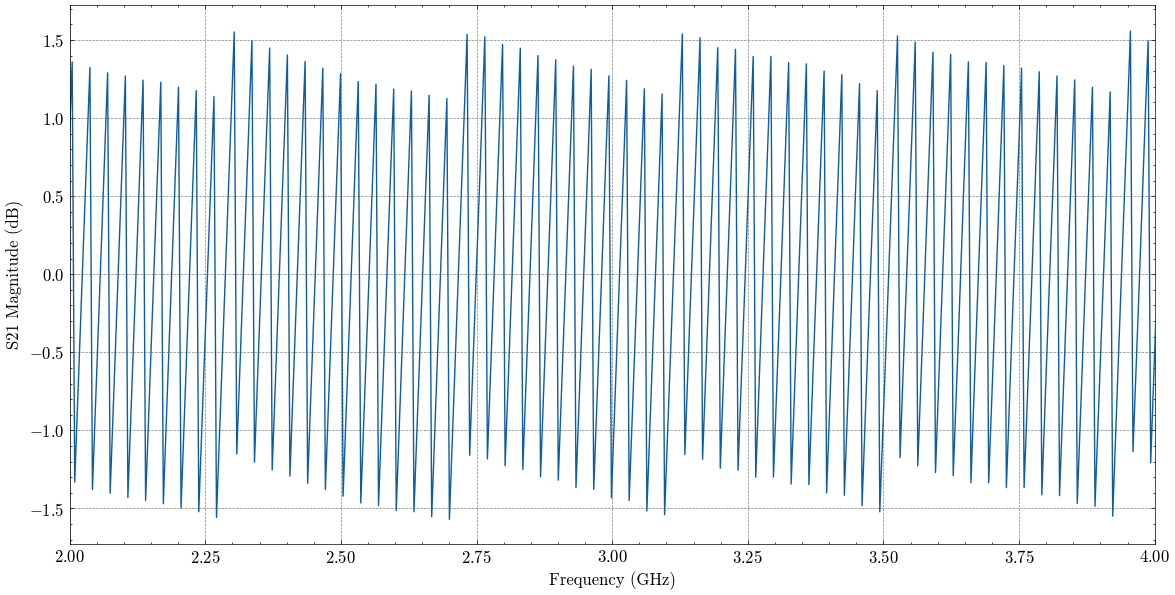

In [ ]:
plt.plot(f/1e9, s21p)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Magnitude (dB)')
plt.xlim(2, 4)
# plt.xlim(2e9, 2.5e9)

# folder_path = Path("b5b6twpa/QubicTech/resonator_DC_bias")
# for f in folder_path.glob("*.txt"):
#     f, s21m, _ = convert_realimag_to_dbdeg(f)
#     plt.plot(f/1e9, s21m)
#     plt.xlabel('Frequency (GHz)')
#     plt.ylabel('S21 Magnitude (dB)')

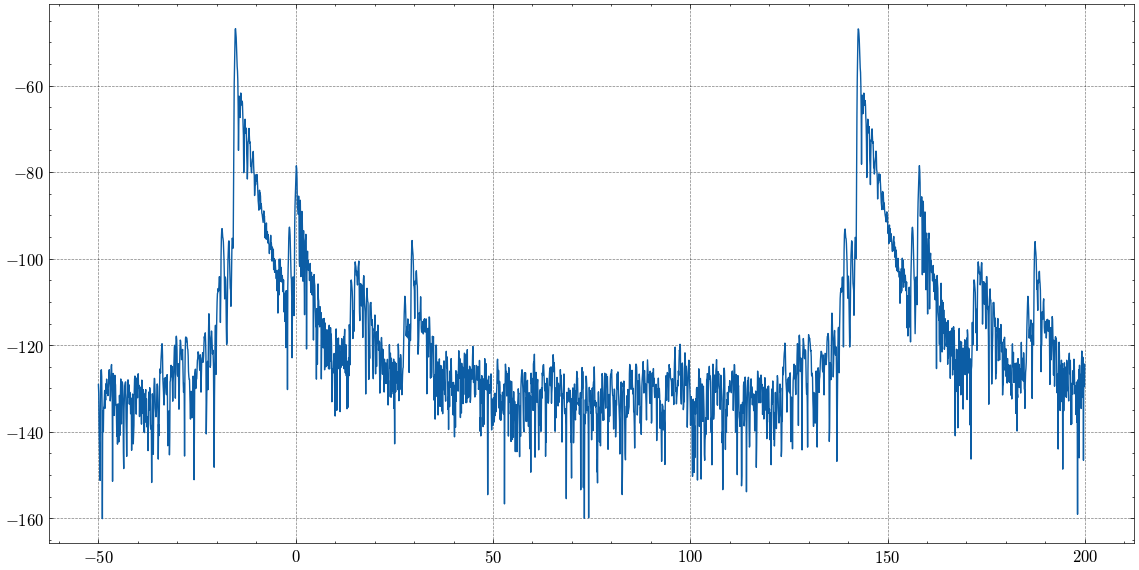

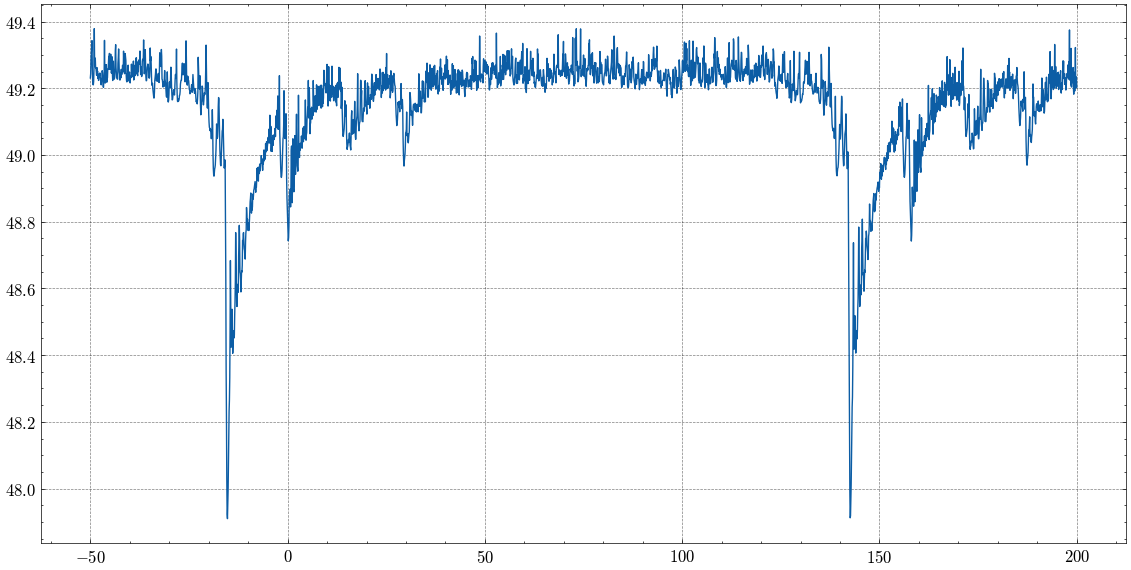

In [ ]:
filename = 'b5b6twpa/QubicTech/50ohm_Time_domain/50ohm_0dBm_S21_time_domaine.txt'
start_writing = False
freqs = []
tdr_data = []
with open(filename, 'r', encoding='utf-8') as file:
    for line in file:
        j = (line.strip())
        if ('#freq(Hz)' in j):
            start_writing = True
        if start_writing == True:
            if (j.split() != []) and (j.find('#freq(Hz)') == -1):
                freqs.append(np.float64(j.split()[0]))
                tdr_data.append(np.float64(j.split()[1]))
freqs = np.array(freqs)
tdr_data = np.array(tdr_data)

impedence = -50 * ((1 + tdr_data)/(1 - tdr_data))

# N = len(freqs)
# df = freqs[1] - freqs[0]
# dt = 1 / (N*df)
# time = np.arange(N) * dt
# distance = 0.8*3e8*time/2

plt.plot(freqs*1e9, tdr_data)
plt.show()

plt.plot(freqs*1e9, impedence)
plt.show()

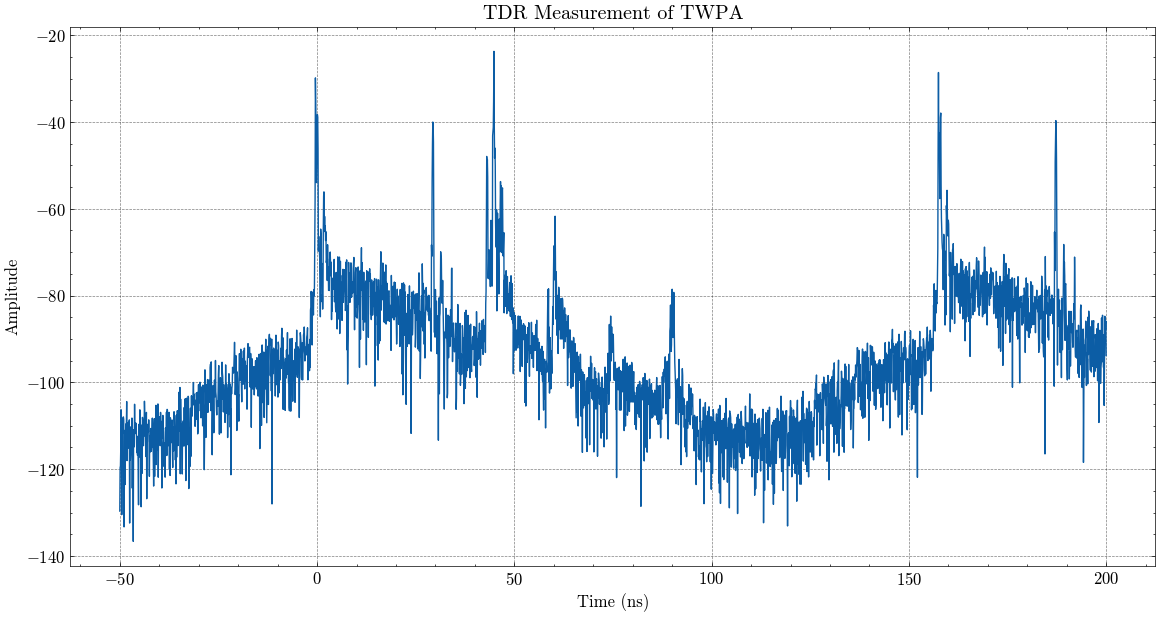

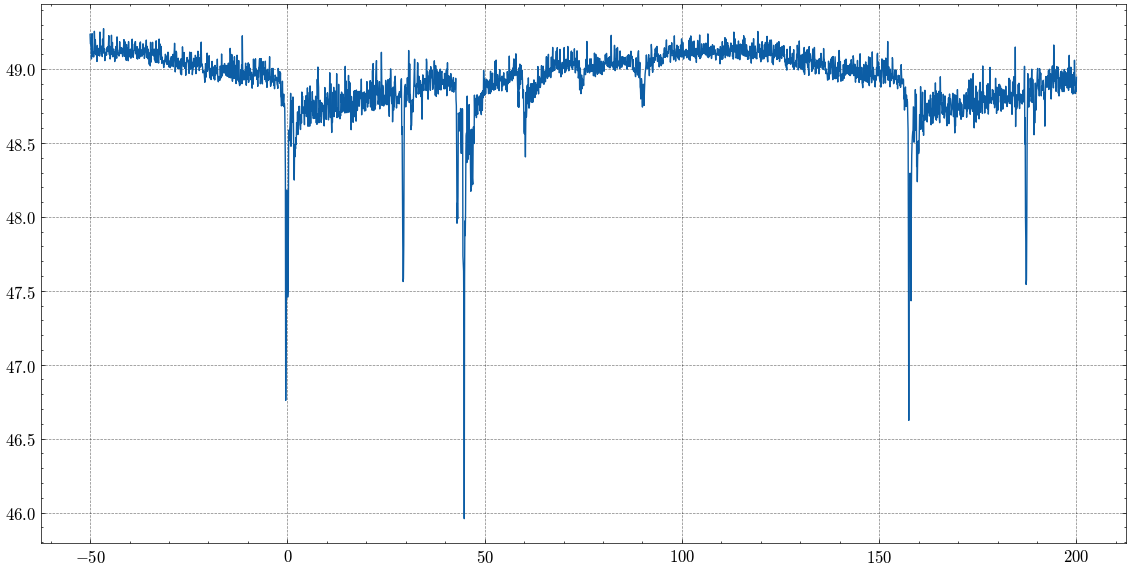

In [ ]:
import numpy as np

filename = 'b5b6twpa/QubicTech/twpa_time_domaine/TWPA_0dBm_S22_time_domaine.txt'
start_writing = False
freqs = []
tdr_data = []
with open(filename, 'r', encoding='utf-8') as file:
    for line in file:
        j = (line.strip())
        if ('#freq(Hz)' in j):
            start_writing = True
        if start_writing == True:
            if (j.split() != []) and (j.find('#freq(Hz)') == -1):
                freqs.append(np.float64(j.split()[0]))
                tdr_data.append(np.float64(j.split()[1]))
freqs = np.array(freqs)
tdr_data = np.array(tdr_data)

impedence = -50 * ((1 + tdr_data)/(1 - tdr_data))

# N = len(freqs)
# df = freqs[1] - freqs[0]
# dt = 1 / (N*df)
# time = np.arange(N) * dt
# distance = 0.8*3e8*time/2

plt.plot(freqs*1e9, tdr_data)
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.title('TDR Measurement of TWPA')
plt.show()

plt.plot(freqs*1e9, impedence)
plt.show()

In [26]:
## Performing the Inverse Fourier Transform on the Gain Ripple Data ##
def gain_ripple_ifft(mag, freq, phase):
    '''
    #######################################################################
    ### This function takes the magnitude, phase and frequency data     ###
    ### of the gain ripple datasets and turns them first into the       ###
    ### time domain data spectrum using the IFFT that we were looking   ###
    ### for. It also attempts to filter out the 'true' peak and perform ###    
    ### an FFT and plot this back in the original frequency domain      ### 
    ### to look at the true 'gain' of the system without these ripples? ###
    #######################################################################
    '''
    
    phase = np.pi/180 * phase
    full_magdata = mag*np.exp(1j*phase)

    full_magdata_time = ifft(full_magdata)
    
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    peaks, _ = find_peaks(full_magdata_time, 2)
    troughs, _ = find_peaks(-full_magdata_time)
    
    mask = np.zeros_like(full_magdata_time)
    mask[(np.where(time >= 2e-8))[0][0] : (np.where(time >= 3.5e-8))[0][0]] = 1
    mask[(np.where(time >= 0))]
    full_magdata_time_peak = full_magdata_time * mask
    
    full_magdata_freq_peak = fft(full_magdata_time_peak)
    full_magdata_freq = fft(full_magdata_time)
    
    # plt.plot(freq, phase, label='Data', color='#ffdc73')
    # # plt.plot(freq, -np.abs(full_magdata_freq_peak), label='FFT Data Filtered', color='dodgerblue')
    # # plt.plot(freq, -np.abs(full_magdata_freq), label='FFTd Data Full')
    # plt.title('Time Domain FFT Investigation')
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('Magnitude')
    # plt.legend()
    # plt.show()
        
    plt.plot(time, full_magdata_time, label='Data')
    plt.plot(time, full_magdata_time_peak, label='Filtered Data', color='peru')
    # plt.plot(time[peaks], full_magdata_time[peaks], 'ro', label='Peaks')
    # plt.plot(time[troughs], full_magdata_time[troughs], 'go', label='Troughs')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Inverse Fourier Transform of Gain Ripple Data')
    plt.ylim(-4, 4)
    plt.xlim(-0.05e-7, 1e-7)
    # plt.xlim(4e9, 4.25e9)
    plt.legend()
    plt.show()
    
    plt.plot(time, full_magdata_time, label='Data')
    # plt.plot(time, full_magdata_time_peak, label='Filtered Data', color='peru')
    # plt.plot(time[peaks], full_magdata_time[peaks], 'ro', label='Peaks')
    # plt.plot(time[troughs], full_magdata_time[troughs], 'go', label='Troughs')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Inverse Fourier Transform of Gain Ripple Data')
    # plt.ylim(-4, 4)
    # plt.xlim(-0.05e-7, 1e-7)
    # plt.xlim(4e9, 4.25e9)
    plt.legend()
    plt.show()


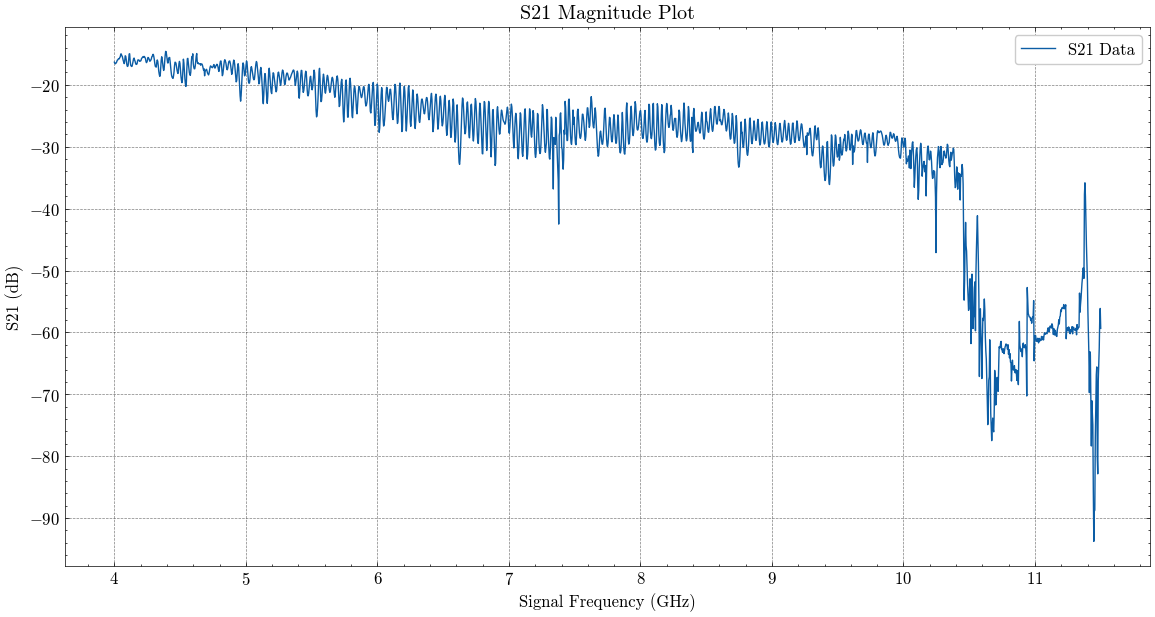

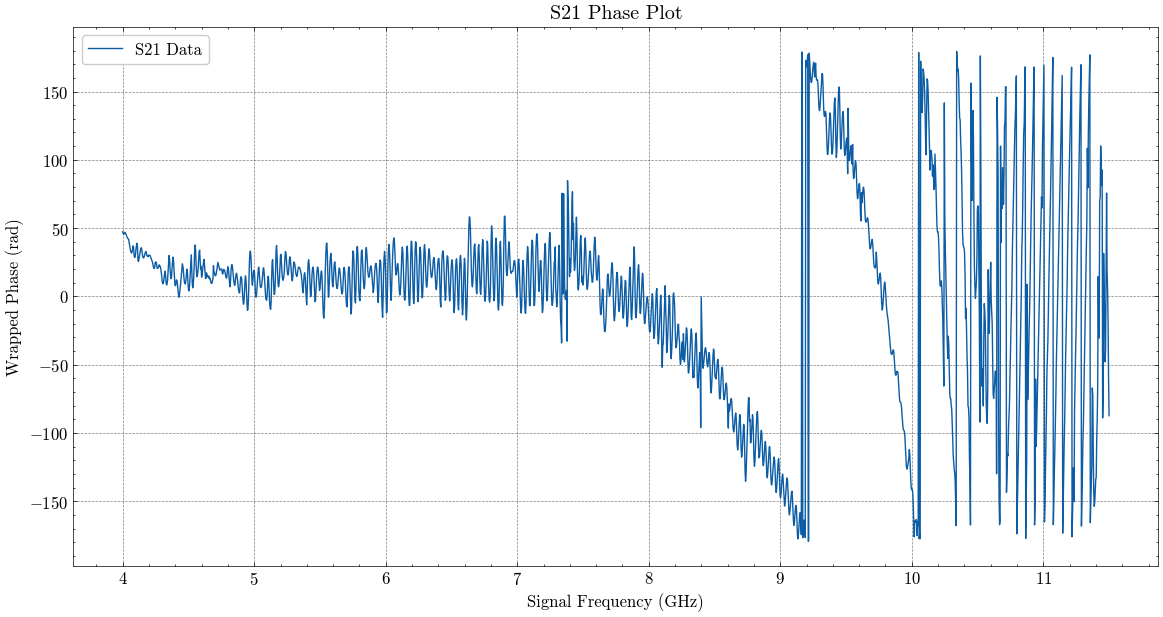

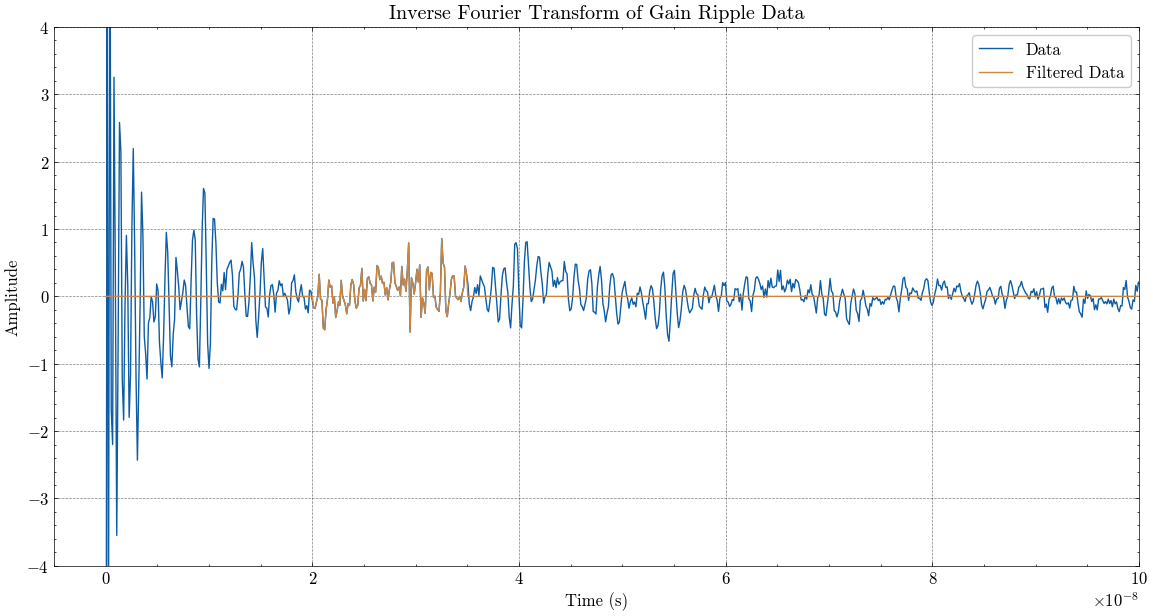

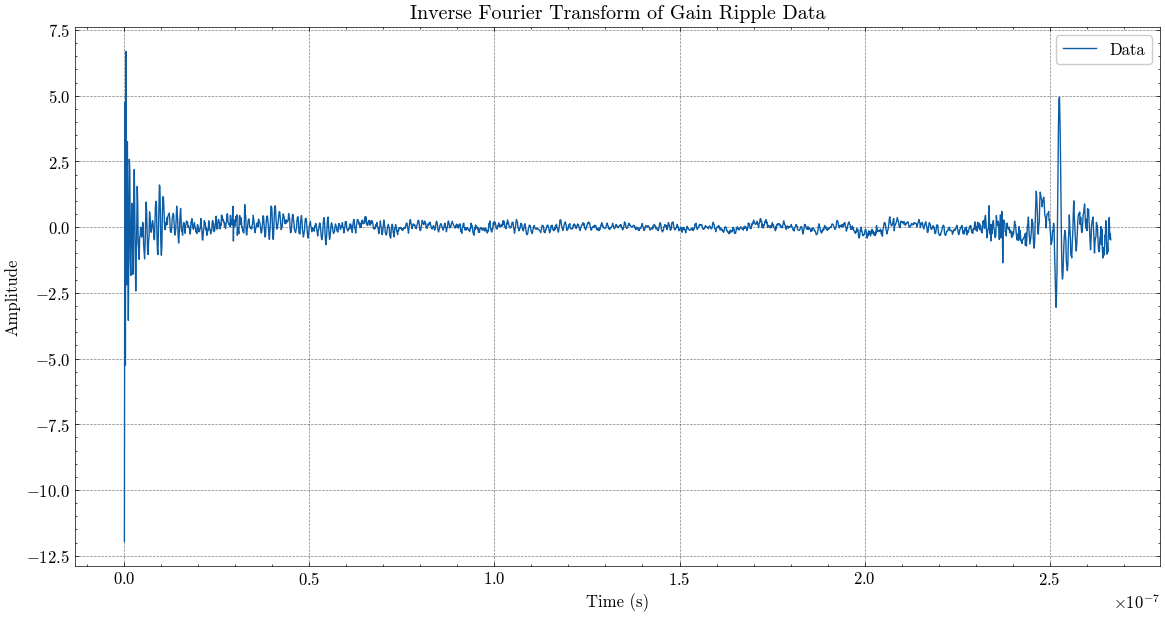

In [33]:
def pump_comparison(mag_file, phase_file):
    mag = h5py.File(mag_file, 'r')
    phase = h5py.File(phase_file, 'r')
    freq_start_on = mag['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop_on = mag['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts_on = mag['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start_on, freq_stop_on, probe_pts_on)
    s21 = np.asarray(mag['sweep_dataframe']).flatten()
    phase = np.asarray(phase['sweep_dataframe']).flatten()
    mask = (freqs >= freq_start_on) & (freqs <= 8000000000.0)
    
    return [freqs, s21, phase, mask]

    
freqs, mag, phase, _ = pump_comparison('full_july_data/01427_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.12V_11.977GHz_7.0_dBm_pump.hdf5', 
                                       'full_july_data/01427_S21_4to5_10dBattprobe_pumpontopPHAS_7.533e-08_edelay_2.12V_11.977GHz_7.0_dBm_pump.hdf5')

# freqs, mag, phase, _ = pump_comparison('data/may_data/00008_S21_lines1to5_10dBattenMLOG_9.015e-08_edelay_2.95V_13.8GHz_12.5_dBm_pump.hdf5', 
#                                        'data/may_data/00008_S21_lines1to5_10dBattenUPH_9.015e-08_edelay_2.95V_13.8GHz_12.5_dBm_pump.hdf5')

# data/may_data/00008_S21_lines1to5_10dBattenUPH_9.015e-08_edelay_2.95V_13.8GHz_12.5_dBm_pump.hdf5
# data/may_data/00008_S21_lines1to5_10dBattenPHAS_9.015e-08_edelay_2.95V_13.8GHz_12.5_dBm_pump.hdf5

plt.plot(freqs/1e9, mag, label='S21 Data')
plt.xlabel('Signal Frequency (GHz)')
plt.ylabel('S21 (dB)')
plt.title('S21 Magnitude Plot')
plt.legend()
plt.show()

plt.plot(freqs/1e9, phase, label='S21 Data')
plt.xlabel('Signal Frequency (GHz)')
plt.ylabel('Wrapped Phase (rad)')
plt.title('S21 Phase Plot')
plt.legend()
plt.show()

gain_ripple_ifft(mag, freqs, phase)